# Chương 4 - Phần 3: Hệ Thống Tìm Kiếm Ảnh Bằng wHash (Nâng Cao)

**Thông tin học viên:**
- **Họ và tên:** Nguyễn Ngọc Anh  
- **Lớp:** CN22H  
- **Môn học:** Thị giác Máy tính (Computer Vision)  

---

## 1. Import Thư Viện & Hàm Hỗ Trợ

Khai báo các thư viện cần thiết và định nghĩa thuật toán tìm kiếm.

In [1]:
import os
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt

%matplotlib inline

def wavelet_hash_standard(image_path, wavelet='db4', level=1, size=(64, 64)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img_resized = cv2.resize(img, size)
    coeffs = pywt.wavedec2(img_resized.astype(np.float32), wavelet, level=level)
    cA = coeffs[0]
    med = np.median(cA)
    return (cA > med).astype(int).flatten().tolist()

def hamming_distance(hash1, hash2):
    return int(np.sum(np.abs(np.array(hash1) - np.array(hash2))))

print("Sẵn sàng triển khai tìm kiếm ảnh!")

Sẵn sàng triển khai tìm kiếm ảnh!


## 2. Tìm Kiếm Ảnh Trên Cơ Sở Dữ Liệu (Database Indexing)

Tạo lập cơ sở dữ liệu gồm 5 ảnh gốc sạch (`base_0_var_0` đến `base_4_var_0`) và tiến hành tìm kiếm ảnh tương đồng nhất với ảnh truy vấn bị nhiễu hạt (`base_0_var_29`).

In [2]:
img_dir = "../data/input/variants"
database = {
    "anh.jpg (Group 0)": os.path.join(img_dir, "base_0_var_0.jpg"),
    "anh1.jpg (Group 1)": os.path.join(img_dir, "base_1_var_0.jpg"),
    "anh2.jpg (Group 2)": os.path.join(img_dir, "base_2_var_0.jpg"),
    "anh3.jpg (Group 3)": os.path.join(img_dir, "base_3_var_0.jpg"),
    "demo.jpg (Group 4)": os.path.join(img_dir, "base_4_var_0.jpg")
}

# Indexing: tính toán mã băm cho database
db_hashes = {name: wavelet_hash_standard(path) for name, path in database.items()}

# Nhận ảnh truy vấn (query) là ảnh biến thể bị nhiễu của ảnh anh.jpg
query_image_path = os.path.join(img_dir, "base_0_var_29.jpg")
query_hash = wavelet_hash_standard(query_image_path)

# Quét database
best_match = None
min_distance = float('inf')

for name, h_code in db_hashes.items():
    dist = hamming_distance(query_hash, h_code)
    print(f"Khoảng cách Hamming giữa ảnh truy vấn và '{name}': {dist}")
    if dist < min_distance:
        min_distance = dist
        best_match = name

print(f"\nKết quả so khớp: Ảnh tương đồng nhất được tìm thấy là '{best_match}' với Hamming distance = {min_distance}")

Khoảng cách Hamming giữa ảnh truy vấn và 'anh.jpg (Group 0)': 78
Khoảng cách Hamming giữa ảnh truy vấn và 'anh1.jpg (Group 1)': 672
Khoảng cách Hamming giữa ảnh truy vấn và 'anh2.jpg (Group 2)': 634
Khoảng cách Hamming giữa ảnh truy vấn và 'anh3.jpg (Group 3)': 708
Khoảng cách Hamming giữa ảnh truy vấn và 'demo.jpg (Group 4)': 612

Kết quả so khớp: Ảnh tương đồng nhất được tìm thấy là 'anh.jpg (Group 0)' với Hamming distance = 78


## 3. Trực Quan Hóa Kết Quả Tìm Kiếm

Hiển thị ảnh truy vấn và kết quả tìm được cạnh nhau và lưu ảnh.

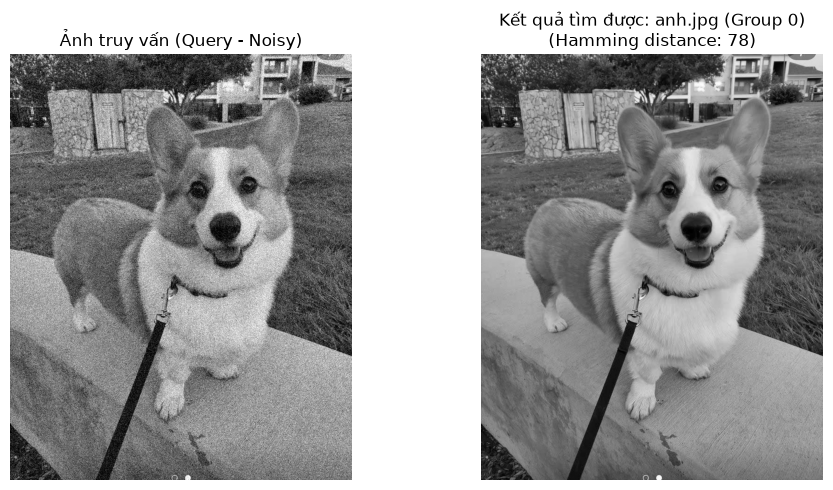

Đã lưu trực quan hóa kết quả tìm kiếm tại: ../outputs/retrieval_result.png


In [3]:
query_img = cv2.imread(query_image_path, cv2.IMREAD_GRAYSCALE)
result_img = cv2.imread(database[best_match], cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(query_img, cmap='gray')
axes[0].set_title("Ảnh truy vấn (Query - Noisy)")
axes[0].axis('off')

axes[1].imshow(result_img, cmap='gray')
axes[1].set_title(f"Kết quả tìm được: {best_match}\n(Hamming distance: {min_distance})")
axes[1].axis('off')

plt.tight_layout()
retrieval_path = "../outputs/retrieval_result.png"
plt.savefig(retrieval_path, dpi=300)
plt.show()
print(f"Đã lưu trực quan hóa kết quả tìm kiếm tại: {retrieval_path}")